In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import xml.etree.ElementTree as ET
import xmlschema
import json
import polars as pl
import networkx as nx
from itertools import zip_longest

In [3]:
import ggblab

In [4]:
from ggblab_extra import ConstructionIO
from ggblab_extra import ConstructionTreeParser

In [5]:
# from ggblab_extra.sympy import point_from_value, segment_from_command, line_from_value, circle_from_value
from ggblab_extra.sympy import expr_from_value
from ggblab_extra.sympy import attach_object2d, attach_object3d, enumerate_plane_members

In [6]:
%ggblab api getVersion()

[ggblab] created GeoGebra singleton and stored as 'ggb' in user namespace


'5.2.909.9'

In [7]:
%ggb api newConstruction()

In [8]:
%%ggb
A = Point(xAxis)
B = Point(yAxis)

['A', 'B']

In [9]:
%ggb api setCoords(A, 2.0, 2.0)
%ggb api setCoords(B, 0.0, -2.0)

In [10]:
%%ggb
Segment(A, B)

['f']

In [11]:
%%ggb
a = Slider[0, 1]

['a']

In [12]:
%%ggb
Point(f, a)
PathParameter(_)

['C', 'b']

In [13]:
%%ggb
Line(A, B)

['g']

In [14]:
%%ggb
# C = Point(xAxis)
Point(yAxis)

['D']

In [15]:
# %ggb api setCoords(C, 1, 0)
%ggb api setCoords(D, 0, 1)

In [16]:
%%ggb
h = Line(C, D)

['h']

In [17]:
%%ggb
l1 = {Intersect[g, h]}
l1(1)

['l1', 'E']

In [18]:
%%ggb
Line(D, f)

['i']

In [19]:
%%ggb
{Intersect[g, i]}

['l2']

In [20]:
df = await ConstructionIO.initialize_dataframe(ggb, use_applet=True)
df["Name", "Type", "Command", "Value"]

Name,Type,Command,Value
str,str,str,str
"""A""","""point""","""Point(xAxis)""","""A = (2, 0)"""
"""B""","""point""","""Point(yAxis)""","""B = (0, -2)"""
"""f""","""segment""","""Segment(A, B)""","""f = 2.8284271247462"""
"""a""","""numeric""",null,"""a = 0.5"""
"""C""","""point""","""Point(f, a)""","""C = (1, -1)"""
"""b""","""numeric""","""PathParameter(C)""","""b = 0.5"""
"""g""","""line""","""Line(A, B)""","""g: x - y = 2"""
"""D""","""point""","""Point(yAxis)""","""D = (0, 1)"""
"""h""","""line""","""Line(C, D)""","""h: -2x - y = -1"""


In [21]:
print(ConstructionIO.commands_for_magic(df, use_name_equals=False))

Point(xAxis)
Point(yAxis)
Segment(_1, _2)
Point(_3, _4)
PathParameter(_5)
Line(_1, _2)
Point(yAxis)
Line(_5, _8)
{Intersect(_7, _9)}
_10(1)
Line(_8, _3)
{Intersect(_7, _12)}


In [55]:
r = await ggb.function('getValueString', ['l1'])
s = expr_from_value(r)
s

{(1.20000000000000, -0.800000000000000)}

In [56]:
r = await ggb.function('getValueString', ['l2'])
s = expr_from_value(r)
s

EmptySet

In [57]:
from sympy import nonlinsolve, linsolve, solve, Eq, discriminant, Matrix, Poly
from sympy import print_mathml, mathml, print_tree, pprint, srepr
from sympy import assuming, ask, Q
from sympy import symbols
x, y, z = symbols('x y z', real=True)
theta = symbols('theta')
pi = symbols('pi')

In [45]:
from sympy import mathml
from IPython.display import Math, HTML

In [65]:
r = await ggb.function('getValueString', ['g'])
s = expr_from_value(r)
print_tree(s, assumptions=False)

Equality: Eq(2*x - 1.47*y, 2.94)
+-Add: 2*x - 1.47*y
| +-Mul: 2*x
| | +-Integer: 2
| | +-Symbol: x
| +-Mul: -1.47*y
|   +-Float: -1.47000000000000
|   +-Symbol: y
+-Float: 2.94000000000000



In [66]:
# mathml_fragment = mathml(s, printer='content')
mathml_fragment = mathml(s, printer='presentation')
mathml_fragment

'<mrow><mrow><mrow><mn>2</mn><mo>&InvisibleTimes;</mo><mi>x</mi></mrow><mo>-</mo><mrow><mn>1.47</mn><mo>&InvisibleTimes;</mo><mi>y</mi></mrow></mrow><mo>=</mo><mn>2.94</mn></mrow>'

In [68]:
# # XXE (&InvisibleTimes;) is undefined

# # import defusedxml.ElementTree as ET
# import xml.etree.ElementTree as ET
# # fragment = ET.fromstring(mathml(s, printer='presentation'))
# # mathml_fragment = "<mrow><mn>2</mn><mo>+</mo><mn>2</mn></mrow>"
# fragment = ET.fromstring(mathml_fragment)
# root = ET.Element("math", xmlns="http://www.w3.org/1998/Math/MathML")
# root.append(fragment)
# result = ET.tostring(root, encoding="unicode")
# display(HTML(result))

In [69]:
from lxml import etree
mml_ns = "http://www.w3.org/1998/Math/MathML"
math_root = etree.Element(f"math", nsmap={None: mml_ns}) 
parser = etree.XMLParser(recover=True)
fragment = etree.fromstring(mathml_fragment, parser=parser)
math_root.append(fragment)
display(HTML(etree.tostring(math_root, pretty_print=True).decode()))

In [48]:
df2 = attach_object2d(df)
df2["Name", "Type", "object2d"]

Name,Type,object2d
str,str,object
"""A""","""point""","Object2D(kind='point', obj=Point2D(2, 0), value='A = (2, 0)', command='Point(xAxis)')"
"""B""","""point""","Object2D(kind='point', obj=Point2D(0, -2), value='B = (0, -2)', command='Point(yAxis)')"
"""f""","""segment""","Object2D(kind='segment', obj=Segment2D(Point2D(2, 0), Point2D(0, -2)), value='f = 2.8284271247462', command='Segment(A, B)')"
"""g""","""line""","Object2D(kind='line', obj=Line2D(Point2D(0, -2), Point2D(1, -1)), value='g: x - y = 2', command='Line(A, B)')"
"""C""","""point""","Object2D(kind='point', obj=Point2D(1, 0), value='C = (1, 0)', command='Point(xAxis)')"
"""D""","""point""","Object2D(kind='point', obj=Point2D(0, 1), value='D = (0, 1)', command='Point(yAxis)')"
"""h""","""line""","Object2D(kind='line', obj=Line2D(Point2D(0, 1), Point2D(1, 0)), value='h: -x - y = -1', command='Line(C, D)')"
"""l1""","""list""",null
"""E""","""point""","Object2D(kind='point', obj=Point2D(3/2, -1/2), value='E = (1.5, -0.5)', command='l1(1)')"


In [49]:
l_1 = df2.filter(pl.col("Name") == "g")["object2d"].item().obj
l_2 = df2.filter(pl.col("Name") == 'h')["object2d"].item().obj

In [50]:
l_1.equation().evalf(), l_2.equation().evalf()

(-x + y + 2.0, x + y - 1.0)

In [51]:
p_1 = list(l_1.intersect(l_2).evalf())[0]
p_1

Point2D(1.50000000000000, -0.500000000000000)

In [52]:
s = linsolve((l_1.equation().evalf(), l_2.equation().evalf()), (x, y))
s

{(1.5, -0.5)}

In [53]:
l_1.distance(p_1)

0

In [54]:
l_1.equation().subs({x: p_1[0], y: p_1[1]})

0

In [140]:
r = await ggb.function('getValueString', ['l1'])
ggb.parser.tokenize(r)

['l1', '=', [['-3.9900497512438', '-2.9950248756219']]]

In [130]:
d1 = l_1.equation().evalf().as_coefficients_dict()
d2 = l_1.equation().evalf().as_coefficients_dict()
d1, d2

(defaultdict(int, {1: 2.00000000000000, x: -1, y: 2.00000000000000}),
 defaultdict(int, {1: 2.00000000000000, x: -1, y: 2.00000000000000}))

In [134]:
Matrix([[d1[x], d1[y], 0]]).cross(Matrix([[d2[x], d2[y], 0]]))

Matrix([[0, 0, 0]])

In [78]:
p = ConstructionTreeParser(df)
g1 = p.parse()
# p.df

In [79]:
nx.write_network_text(g1)

╟── xAxis
╎   └─╼ A
╎       ├─╼ f ╾ B
╎       │   ├─╼ C ╾ a
╎       │   │   ├─╼ b
╎       │   │   └─╼ h ╾ D
╎       │   │       └─╼ l1 ╾ g
╎       │   │           └─╼ E
╎       │   └─╼ i ╾ D
╎       │       └─╼ l2 ╾ g
╎       └─╼ g ╾ B
╎           └─╼  ...
╟── yAxis
╎   ├─╼ B
╎   │   └─╼  ...
╎   └─╼ D
╎       └─╼  ...
╟── a
╎   └─╼  ...
╟── l1
╙── l2


In [80]:
list(nx.ancestors(g1, 'l1__list')), list(nx.ancestors(g1, 'l2__list'))

(['xAxis', 'yAxis', 'f', 'A', 'C', 'g', 'D', 'h', 'a', 'B'],
 ['f', 'xAxis', 'yAxis', 'A', 'i', 'g', 'B', 'D'])

In [81]:
from networkx.readwrite import json_graph
json_graph.node_link_data(g1)

{'directed': True,
 'multigraph': False,
 'graph': {},
 'nodes': [{'id': 'xAxis'},
  {'Type': 'point', 'id': 'A'},
  {'id': 'yAxis'},
  {'Type': 'point', 'id': 'B'},
  {'Type': 'segment', 'id': 'f'},
  {'Type': 'point', 'id': 'C'},
  {'Type': 'numeric', 'id': 'a'},
  {'Type': 'numeric', 'id': 'b'},
  {'Type': 'line', 'id': 'g'},
  {'Type': 'point', 'id': 'D'},
  {'Type': 'line', 'id': 'h'},
  {'Type': 'list', 'id': 'l1'},
  {'Type': 'point', 'id': 'E'},
  {'Type': 'line', 'id': 'i'},
  {'group_members': ['E'],
   'label': 'l1',
   'Type': 'list_group',
   'id': 'l1__list'},
  {'group_members': [], 'label': 'l2', 'Type': 'list_group', 'id': 'l2__list'},
  {'Type': 'list', 'id': 'l2'}],
 'edges': [{'source': 'xAxis', 'target': 'A'},
  {'source': 'A', 'target': 'f'},
  {'source': 'A', 'target': 'g'},
  {'source': 'yAxis', 'target': 'B'},
  {'source': 'yAxis', 'target': 'D'},
  {'source': 'B', 'target': 'f'},
  {'source': 'B', 'target': 'g'},
  {'source': 'f', 'target': 'C'},
  {'source': 

In [84]:
nx.descendants(g1, 'l1__list')

{'E'}

In [83]:
labels_map = {}
for n, t in p.df["Name", "Type"].rows():
    g1.nodes[n]["label"] = f"{n} ({t})"
nx.set_node_attributes(g1, labels_map, "label")
nx.write_network_text(g1, with_labels="label")

╟── xAxis
╎   └─╼ A (point)
╎       ├─╼ f (segment) ╾ B (point)
╎       │   ├─╼ C (point) ╾ a (numeric)
╎       │   │   ├─╼ b (numeric)
╎       │   │   └─╼ h (line) ╾ D (point)
╎       │   │       └─╼ l1 ╾ g (line)
╎       │   │           └─╼ E (point)
╎       │   └─╼ i (line) ╾ D (point)
╎       │       └─╼ l2 ╾ g (line)
╎       └─╼ g (line) ╾ B (point)
╎           └─╼  ...
╟── yAxis
╎   ├─╼ B (point)
╎   │   └─╼  ...
╎   └─╼ D (point)
╎       └─╼  ...
╟── a (numeric)
╎   └─╼  ...
╟── l1 (list)
╙── l2 (list)


In [81]:
nx.ancestors(g1, 'A'), nx.descendants(g1, 'A')

({'xAxis'}, {'f', 'g'})

In [82]:
nx.ancestors(g1, 'f'), nx.descendants(g1, 'f')

({'A', 'B', 'xAxis', 'yAxis'}, set())

In [83]:
p.roots, p.leaves

(['xAxis', 'yAxis', 'l1'], ['f', 'g', 'h', 'E'])

In [84]:
for n in p.roots:
    print(list(g1.neighbors(n)))

['A', 'C']
['B', 'D']
['E']


In [97]:
with assuming(Q.rational(x)):
    print(ask(Q.real(x)))
    # print_tree(x)

True
Symbol: x
commutative: True
complex: True
extended_real: True
finite: True
hermitian: True
imaginary: False
infinite: False
real: True



In [81]:
a = 1
type(a), type(x), x.is_real

(int, sympy.core.symbol.Symbol, True)

In [86]:
x.subs({x: 1}), x

(1, x)

In [87]:
(x+y).subs({x: 2, y: 1})

3

In [73]:
print_tree(x, assumptions=True)

Symbol: x
commutative: True
complex: True
extended_real: True
finite: True
hermitian: True
imaginary: False
infinite: False
real: True



In [32]:
r = await ggb.function('getCommandString', ['f'])
s = segment_from_command(r, df)

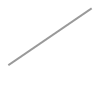

In [33]:
s.evalf()

In [34]:
type(s)

sympy.geometry.line.Segment2D

In [39]:
r = await ggb.function('getValueString', ['g'])
s1 = line_from_value(r)

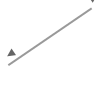

In [40]:
s1.evalf()

In [42]:
type(s1)

ggblab_extra.sympy.line.Line

In [74]:
s1.equation().evalf()

-1.46*x + 2.14*y + 3.1244

In [75]:
print_tree(_, assumptions=False)

Add: -1.46*x + 2.14*y + 3.1244
+-Float: 3.12440000000000
+-Mul: 2.14*y
| +-Float: 2.14000000000000
| +-Symbol: y
+-Mul: -1.46*x
  +-Float: -1.46000000000000
  +-Symbol: x



In [65]:
d1 = s1.equation().evalf().as_coefficients_dict()
d1

defaultdict(int,
            {1: 3.12440000000000, y: 2.14000000000000, x: -1.46000000000000})

In [68]:
# c1 = Poly(s1.equation().evalf(), x, y).as_dict()
# c1

In [69]:
# c1 = Poly(s1.equation().evalf(), x, y).coeffs()
# c1

In [70]:
%%ggb
u = Vector(({d1[x]}, {d1[y]}))
v = Translate(_, A)

['u', 'v']

In [71]:
%%ggb
w = Vector(({d1[y]}, -{d1[x]}))
a = Translate(_, A)

['w', 'a']

In [159]:
%%ggb
{theta} = Slider[0, 2{pi}, 2/90{pi}]

['θ']

In [152]:
p_a = df2.filter(pl.col("Name") == 'A')["object2d"].item().obj

In [156]:
from sympy import symbols, Matrix, cos, sin, pi

In [157]:
m1 = Matrix([[1, 0, p_a[0]], [0, 1, p_a[1]], [0, 0, 1]])
m2 = Matrix([[cos(theta), -sin(theta), 0], [sin(theta), cos(theta), 0], [0, 0, 1]])

In [158]:
%%ggb
m1 = {m1}
m2 = {m2}

['m1', 'm2']

In [88]:
for e in (await ggb.function('getAllObjectNames')):
    print(await ggb.function('getXML', [e]))

<element type="point" label="A">
	<show object="true" label="true"/>
	<objColor r="21" g="101" b="192" alpha="0"/>
	<layer val="0"/>
	<labelMode val="0"/>
	<animation step="0.1" type="1" playing="false"/>
	<pointSize val="5"/>
	<pointStyle val="0"/>
	<coords x="1.61" y="0" z="1"/>
</element>

<element type="point" label="B">
	<show object="true" label="true"/>
	<objColor r="21" g="101" b="192" alpha="0"/>
	<layer val="0"/>
	<labelMode val="0"/>
	<animation step="0.1" type="1" playing="false"/>
	<pointSize val="5"/>
	<pointStyle val="0"/>
	<coords x="0" y="-1.99" z="1"/>
</element>

<element type="segment" label="f">
	<show object="true" label="true"/>
	<objColor r="0" g="0" b="0" alpha="0"/>
	<layer val="0"/>
	<labelMode val="0"/>
	<lineStyle thickness="5" type="0" typeHidden="1" opacity="178"/>
	<eqnStyle style="implicit"/>
	<outlyingIntersections val="false"/>
	<keepTypeOnTransform val="true"/>
	<startStyle val="default"/>
	<endStyle val="default"/>
	<coords x="1.99" y="-1.61" z="-3.

In [89]:
r = await ggb.function('getXML')

In [90]:
root = ET.fromstring(r)
x = ET.tostring(root.find('.//construction'), encoding='unicode')
print(x)

<construction title="" author="" date="">
<command name="Point">
	<input a0="xAxis" />
	<output a0="A" />
</command>
<element type="point" label="A">
	<show object="true" label="true" />
	<objColor r="21" g="101" b="192" alpha="0" />
	<layer val="0" />
	<labelMode val="0" />
	<animation step="0.1" type="1" playing="false" />
	<pointSize val="5" />
	<pointStyle val="0" />
	<coords x="1.61" y="0" z="1" />
</element>
<command name="Point">
	<input a0="yAxis" />
	<output a0="B" />
</command>
<element type="point" label="B">
	<show object="true" label="true" />
	<objColor r="21" g="101" b="192" alpha="0" />
	<layer val="0" />
	<labelMode val="0" />
	<animation step="0.1" type="1" playing="false" />
	<pointSize val="5" />
	<pointStyle val="0" />
	<coords x="0" y="-1.99" z="1" />
</element>
<command name="Segment">
	<input a0="A" a1="B" />
	<output a0="f" />
</command>
<element type="segment" label="f">
	<show object="true" label="true" />
	<objColor r="0" g="0" b="0" alpha="0" />
	<layer val

In [97]:
o['element'][0]['coords'][0] = {'@x': '2', '@y': '2', '@z': '0'}

In [91]:
o = ggb.file.ggb_schema.decode(x)
o

{'@title': '',
 '@author': '',
 '@date': '',
 'command': [{'@name': 'Point',
   'input': {'@a0': 'xAxis'},
   'output': {'@a0': 'A'}},
  {'@name': 'Point', 'input': {'@a0': 'yAxis'}, 'output': {'@a0': 'B'}},
  {'@name': 'Segment',
   'input': {'@a0': 'A', '@a1': 'B'},
   'output': {'@a0': 'f'}},
  {'@name': 'Line', 'input': {'@a0': 'A', '@a1': 'B'}, 'output': {'@a0': 'g'}},
  {'@name': 'Point', 'input': {'@a0': 'xAxis'}, 'output': {'@a0': 'C'}},
  {'@name': 'Point', 'input': {'@a0': 'yAxis'}, 'output': {'@a0': 'D'}},
  {'@name': 'Line',
   'input': {'@a0': 'C', '@a1': 'D'},
   'output': {'@a0': 'h'}}],
 'element': [{'@type': 'point',
   '@label': 'A',
   'show': [{'@object': True, '@label': True}],
   'objColor': [{'@r': 21, '@g': 101, '@b': 192, '@alpha': 0.0}],
   'layer': [{'@val': 0}],
   'labelMode': [{'@val': 0}],
   'animation': [{'@step': '0.1', '@type': 1, '@playing': False}],
   'pointSize': [{'@val': 5.0}],
   'pointStyle': [{'@val': 0}],
   'coords': [{'@x': '1.61', '@y': '

In [92]:
# print(json.dumps(o, indent=None).replace(',', ',\n'))

In [93]:
import jsbeautifier
opts = jsbeautifier.default_options()
opts.indent_size = 2
opts.wrap_line_length = 80
opts.keep_array_indentation = True
opts.brace_style = "preserve-inline"
print(jsbeautifier.beautify(json.dumps(o, indent=None), opts))

{ "@title": "", "@author": "", "@date": "", "command": [
{ "@name": "Point", "input": { "@a0": "xAxis" }, "output": { "@a0": "A" } },
  { "@name": "Point", "input": { "@a0": "yAxis" }, "output": { "@a0": "B" } },
  { "@name": "Segment", "input": { "@a0": "A", "@a1": "B" }, "output": { "@a0": "f" } },
  { "@name": "Line", "input": { "@a0": "A", "@a1": "B" }, "output": { "@a0": "g" } },
  { "@name": "Point", "input": { "@a0": "xAxis" }, "output": { "@a0": "C" } },
  { "@name": "Point", "input": { "@a0": "yAxis" }, "output": { "@a0": "D" } },
  { "@name": "Line", "input": { "@a0": "C", "@a1": "D" }, "output": { "@a0": "h" } }], "element": [
  { "@type": "point", "@label": "A", "show": [
  { "@object": true, "@label": true }], "objColor": [
{ "@r": 21, "@g": 101, "@b": 192, "@alpha": 0.0 }], "layer": [
    { "@val": 0 }], "labelMode": [{ "@val": 0 }], "animation": [
    { "@step": "0.1", "@type": 1, "@playing": false }], "pointSize": [
    { "@val": 5.0 }], "pointStyle": [{ "@val": 0 }], "